# Hail V1 - Full-CONUS MRMS-Only M1 Hazard Layer

**Peril:** hail - **Layer:** M1 hazard layer - **Product:** `hazard_conus_grid` V1

This notebook consumes the reconciled full-CONUS MRMS M0 daily cell evidence and writes one M1 row per
served benchmark `cell_id`.

It deliberately does **not** de-bias MESH, fit EVT tails, use MYRORSS, or run M2-M4 risk metrics. Its job is
the first full-CONUS storage-boundary artifact:

```text
reconciled M0 cell_id x date evidence
  -> per-cell severe-hail-day frequency
  -> raw/provisional MESH severity summaries
  -> explicit severity-tail QA flags
  -> one M1 row per served cell_id
```

Policy references:

- `docs/extra/discussion/conus_grid/hail/03_mrms_tail_qa_and_m1_policy.md`
- `docs/plans/hazard_conus_grid/hail/v1_mrms_only_grid_build.md`
- `docs/plans/hazard_conus_grid/output_schema.md`
- `docs/principles/notebook_work/exploratory_data_notebooks.md`

## 0 - Scope and controls

This notebook should be runnable locally because it streams compact daily parquet partitions. It does not
read raw MRMS GRIB files.

Override controls:

```bash
MRMS_M0_RECONCILED_RUN_ID=20260616T225000Z_m0_full_conus_reconciled
HAZARD_CONUS_GRID_M1_RUN_ID=YYYYMMDDTHHMMSSZ_m1_mrms_only
HAZARD_CONUS_GRID_UPLOAD_TO_GCS=1
HAZARD_CONUS_GRID_FORCE_M1_OUTPUT=1
```

In [1]:
from __future__ import annotations

import json
import os
import subprocess
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.colors import LogNorm

from hail.m1_hazard_layer import build_m1_hazard_layer
from hail.plausibility_qc import apply_plausibility_qc

plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.25, "figure.dpi": 130})


def repo_root() -> Path:
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "AGENTS.md").exists():
            return candidate
    raise FileNotFoundError("repo root not found")


ROOT = repo_root()
RECONCILED_RUN_ID = os.environ.get("MRMS_M0_RECONCILED_RUN_ID", "20260616T225000Z_m0_full_conus_reconciled")
M1_RUN_ID = os.environ.get(
    "HAZARD_CONUS_GRID_M1_RUN_ID",
    datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ_m1_mrms_only"),
)
UPLOAD_TO_GCS = os.environ.get("HAZARD_CONUS_GRID_UPLOAD_TO_GCS", "0").lower() in {"1", "true", "yes"}
FORCE_M1_OUTPUT = os.environ.get("HAZARD_CONUS_GRID_FORCE_M1_OUTPUT", "0").lower() in {"1", "true", "yes"}

HAIL_GRID_DIR = ROOT / "data" / "hazard_conus_grid" / "hail" / "v1_mrms_only"
RECONCILED_ROOT = HAIL_GRID_DIR / "m0_reconciled_daily_cell_evidence" / f"run_id={RECONCILED_RUN_ID}"
M1_ROOT = HAIL_GRID_DIR / "m1_hazard_layer" / f"run_id={M1_RUN_ID}"
MAP_DIR = M1_ROOT / "maps"
TABLE_DIR = M1_ROOT / "tables"

RECONCILED_METADATA_JSON = RECONCILED_ROOT / f"metadata_{RECONCILED_RUN_ID}.json"
DATE_COVERAGE_CSV = RECONCILED_ROOT / f"mrms_v1_m0_reconciled_date_coverage_{RECONCILED_RUN_ID}.csv"

M1_GCS_ROOT = (
    "gs://infrasure-benchmark/hazard_conus_grid/dev/hail/v1_mrms_only/"
    f"m1_hazard_layer/run_id={M1_RUN_ID}"
)

HAZARD_LAYER_PARQUET = TABLE_DIR / f"mrms_v1_m1_hazard_layer_{M1_RUN_ID}.parquet"
HAZARD_LAYER_CSV = TABLE_DIR / f"mrms_v1_m1_hazard_layer_preview_{M1_RUN_ID}.csv"
SUMMARY_CSV = TABLE_DIR / f"mrms_v1_m1_summary_{M1_RUN_ID}.csv"
TOP_CELLS_CSV = TABLE_DIR / f"mrms_v1_m1_top_cells_{M1_RUN_ID}.csv"
METADATA_JSON = M1_ROOT / f"metadata_{M1_RUN_ID}.json"

print("repo root:", ROOT)
print("input reconciled run:", RECONCILED_RUN_ID)
print("input root:", RECONCILED_ROOT.relative_to(ROOT))
print("M1 run:", M1_RUN_ID)
print("M1 output root:", M1_ROOT.relative_to(ROOT))
print("M1 GCS root:", M1_GCS_ROOT)
print("upload_to_gcs:", UPLOAD_TO_GCS)

repo root: /Users/divy/code/work/infrasure_git_codes/Hazard_modeling
input reconciled run: 20260616T225000Z_m0_full_conus_reconciled
input root: data/hazard_conus_grid/hail/v1_mrms_only/m0_reconciled_daily_cell_evidence/run_id=20260616T225000Z_m0_full_conus_reconciled
M1 run: 20260618T040000Z_m1_mrms_only
M1 output root: data/hazard_conus_grid/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only
M1 GCS root: gs://infrasure-benchmark/hazard_conus_grid/dev/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only
upload_to_gcs: True


## 1 - Input contract and field interpretation

The input is already the reconciled M0 layer:

```text
one row per accepted MRMS source date x served CONUS cell_id
```

M1 collapses those daily rows into one hazard row per `cell_id`.

In [2]:
with RECONCILED_METADATA_JSON.open() as f:
    reconciled_metadata = json.load(f)

partition_paths = sorted(RECONCILED_ROOT.glob("date=*/part-000.parquet"))
date_coverage = pd.read_csv(DATE_COVERAGE_CSV)

expected_dates = int(reconciled_metadata["n_dates"])
expected_cells = int(reconciled_metadata["n_served_cells"])
expected_rows = int(reconciled_metadata["n_output_rows"])

input_contract = pd.DataFrame(
    [
        ("reconciled_run_id", RECONCILED_RUN_ID, "run", "M0 input being summarized"),
        ("accepted_source_dates", expected_dates, "dates", "frequency denominator"),
        ("served_cells", expected_cells, "cells", "M1 output row denominator"),
        ("expected_cell_day_rows", expected_rows, "rows", "M0 row contract"),
        ("partition_files_found", len(partition_paths), "files", "daily partition count"),
        ("date_coverage_rows", len(date_coverage), "rows", "accepted date coverage sidecar"),
    ],
    columns=["item", "value", "unit/base", "why it matters"],
)
display(input_contract)

if len(partition_paths) != expected_dates:
    raise AssertionError(f"found {len(partition_paths)} daily partitions, expected {expected_dates}")
if len(date_coverage) != expected_dates:
    raise AssertionError(f"date coverage rows {len(date_coverage)} != expected {expected_dates}")
if expected_rows != expected_dates * expected_cells:
    raise AssertionError("metadata row contract does not equal dates x cells")

field_dictionary = pd.DataFrame(
    [
        ("cell_id", "benchmark grid join key", "integer", "M1 row identity"),
        ("date", "accepted MRMS source date", "date", "frequency denominator"),
        ("coverage_status", "cell-day evidence state", "category", "separates zero from no-data"),
        ("n_native_pixels_observed", "native pixels assigned/read for cell-day", "count", "coverage QA"),
        ("n_native_pixels_severe", "native pixels with MESH >= 25.4 mm", "count", "severe-day flag and footprint proxy"),
        ("hail_day_flag", "whether n_native_pixels_severe > 0", "boolean", "M1 count process"),
        ("mesh_max_mm", "daily max raw MESH in the cell", "mm", "raw/provisional severity sample"),
        ("mesh_mean_severe_mm", "mean MESH among severe native pixels", "mm", "secondary severity/footprint context"),
        ("threshold_mm", "severe-hail threshold", "mm", "25.4 mm / one inch threshold"),
        ("source_key", "MRMS source object key", "path", "provenance"),
    ],
    columns=["field", "what it is", "units / reference base", "how M1 uses it"],
)
display(field_dictionary)

,item,value,unit/base,why it matters
0,reconciled_run_id,20260616T225000Z_m0_full_conus_reconciled,run,M0 input being summarized
1,accepted_source_dates,2071,dates,frequency denominator
2,served_cells,13085,cells,M1 output row denominator
3,expected_cell_day_rows,27099035,rows,M0 row contract
4,partition_files_found,2071,files,daily partition count
5,date_coverage_rows,2071,rows,accepted date coverage sidecar


,field,what it is,units / reference base,how M1 uses it
0,cell_id,benchmark grid join key,integer,M1 row identity
1,date,accepted MRMS source date,date,frequency denominator
2,coverage_status,cell-day evidence state,category,separates zero from no-data
3,n_native_pixels_observed,native pixels assigned/read for cell-day,count,coverage QA
4,n_native_pixels_severe,native pixels with MESH >= 25.4 mm,count,severe-day flag and footprint proxy
5,hail_day_flag,whether n_native_pixels_severe > 0,boolean,M1 count process
6,mesh_max_mm,daily max raw MESH in the cell,mm,raw/provisional severity sample
7,mesh_mean_severe_mm,mean MESH among severe native pixels,mm,secondary severity/footprint context
8,threshold_mm,severe-hail threshold,mm,25.4 mm / one inch threshold
9,source_key,MRMS source object key,path,provenance


**Takeaway.** The denominator is explicit and already reconciled. M1 must not invent missing dates or
silently turn no-data into no-hail.

## 2 - Build the M1 hazard layer

The full reconciled M0 layer is 27.1M cell-day rows. The `hail` pipeline streams one daily
partition at a time, keeping only compact per-cell accumulators plus the severe cell-days needed
for exact raw-MESH quantiles, then assembles the one-row-per-cell M1 layer.

The build is **asset-free** — the peril side of the M0/M1 vs M2-M4 boundary — and lives in
`pipelines/hail` (`build_m1_hazard_layer`) so this notebook and the production grid driver call
the **same** code. The 52-column contract is `M1_HAZARD_LAYER_COLUMNS`; this notebook adds one
display column (`max_mesh_mm_log1p_display`) in the QA-maps step below.

In [3]:
hazard_layer, m1_diag = build_m1_hazard_layer(
    partition_paths,
    date_coverage,
    reconciled_metadata,
    m1_run_id=M1_RUN_ID,
    reconciled_run_id=RECONCILED_RUN_ID,
)
# Plausibility QC (asset-free): physical severity cap + flags; frequency untouched.
# Decided rule: docs/extra/discussion/conus_grid/hail/05_plausibility_qc_rule.md.
hazard_layer, qc_summary = apply_plausibility_qc(hazard_layer)
print(f"streamed cell-days: {m1_diag['streamed_rows']:,}")
print(f"severe cell-day samples: {m1_diag['severe_cell_day_samples']:,}")
print(f"streaming scan elapsed seconds: {m1_diag['scan_elapsed_seconds']}")
print(
    f"plausibility QC: capped max {qc_summary['max_capped_mesh_mm']:.1f} mm "
    f"(raw {qc_summary['max_raw_mesh_mm']:.0f} mm); {qc_summary['n_hard_artifact']} hard artifacts; "
    f"{qc_summary['n_frequency_spike']} frequency-spike cells held out of reportable loss"
)

display(hazard_layer.head())
display(
    hazard_layer[
        [
            "n_observed_days",
            "n_severe_hail_days",
            "lambda_cell_raw",
            "max_mesh_mm_raw_any_day",
            "extreme_mesh_cell_day_count",
        ]
    ]
    .describe(percentiles=[0.5, 0.9, 0.95, 0.99])
    .T
)
display(hazard_layer["severity_magnitude_status"].value_counts().rename_axis("status").reset_index(name="cells"))

processed 1/2,071 daily partitions


processed 250/2,071 daily partitions


processed 500/2,071 daily partitions


processed 750/2,071 daily partitions


processed 1,000/2,071 daily partitions


processed 1,250/2,071 daily partitions


processed 1,500/2,071 daily partitions


processed 1,750/2,071 daily partitions


processed 2,000/2,071 daily partitions


processed 2,071/2,071 daily partitions
streaming scan elapsed seconds: 14.79
severe cell-day samples: 156170


**Takeaway.** This is now the full 13,085-cell M1 interface object. Frequency is ready as an MRMS-only V1
screening field; severity remains raw/provisional and explicitly flags the tail.

## 3 - QA maps

These maps are review aids. They are not release cartography.

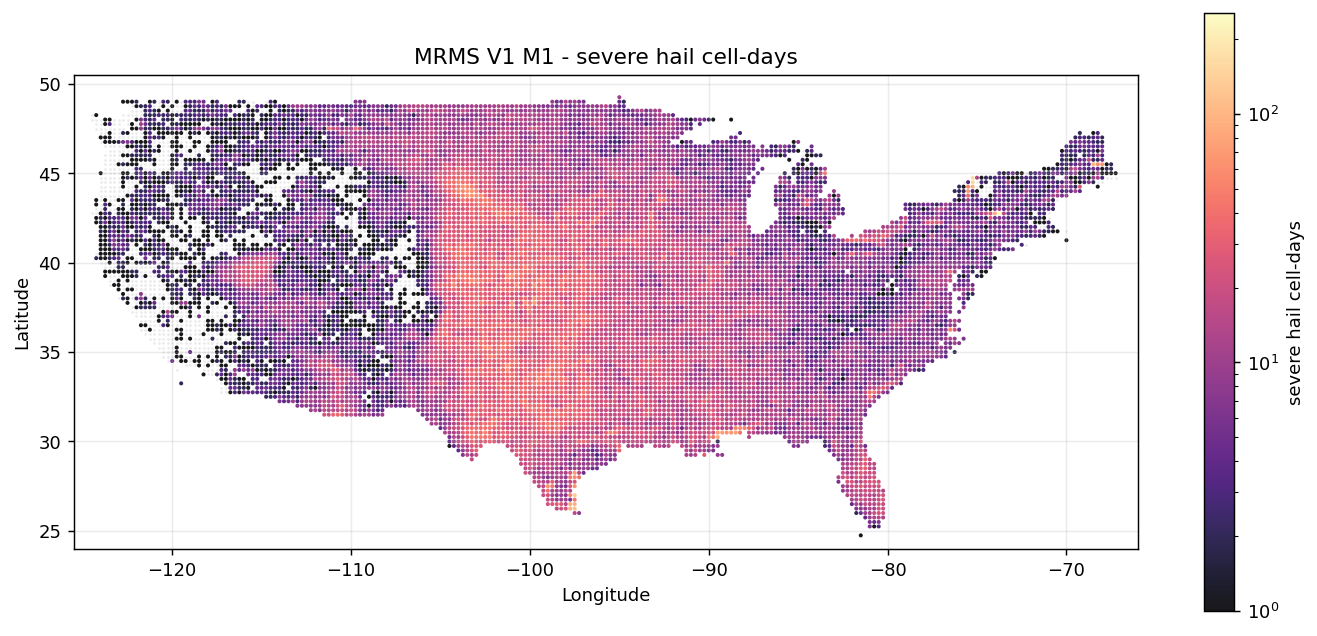

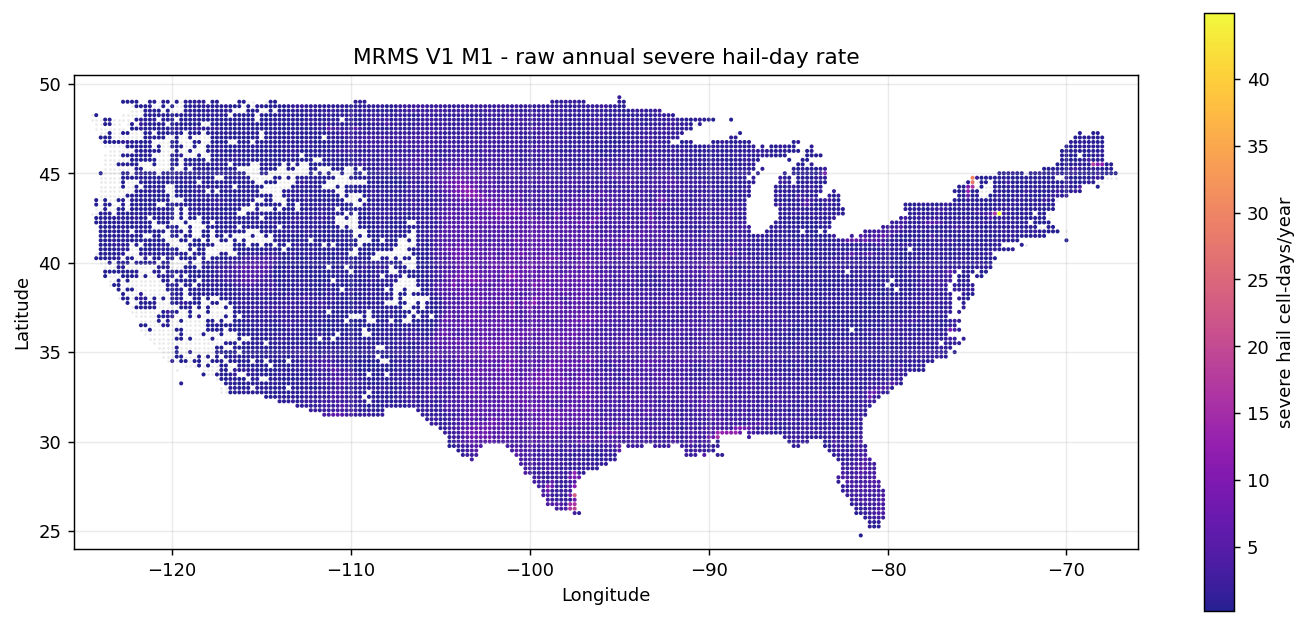

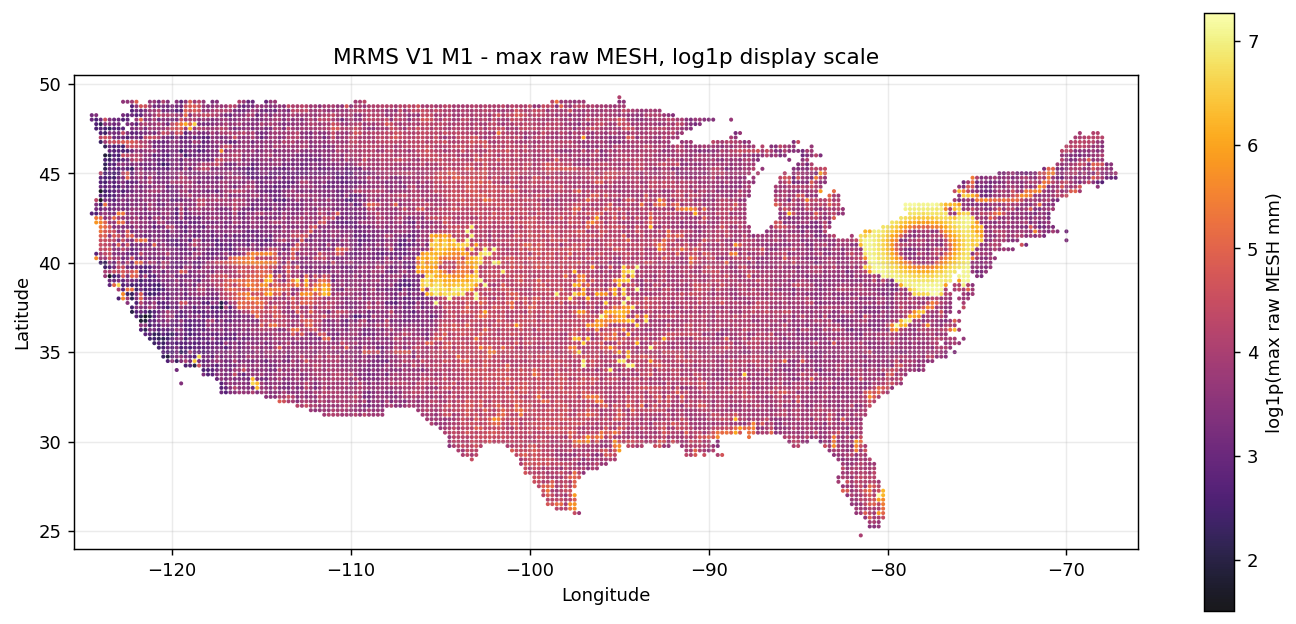

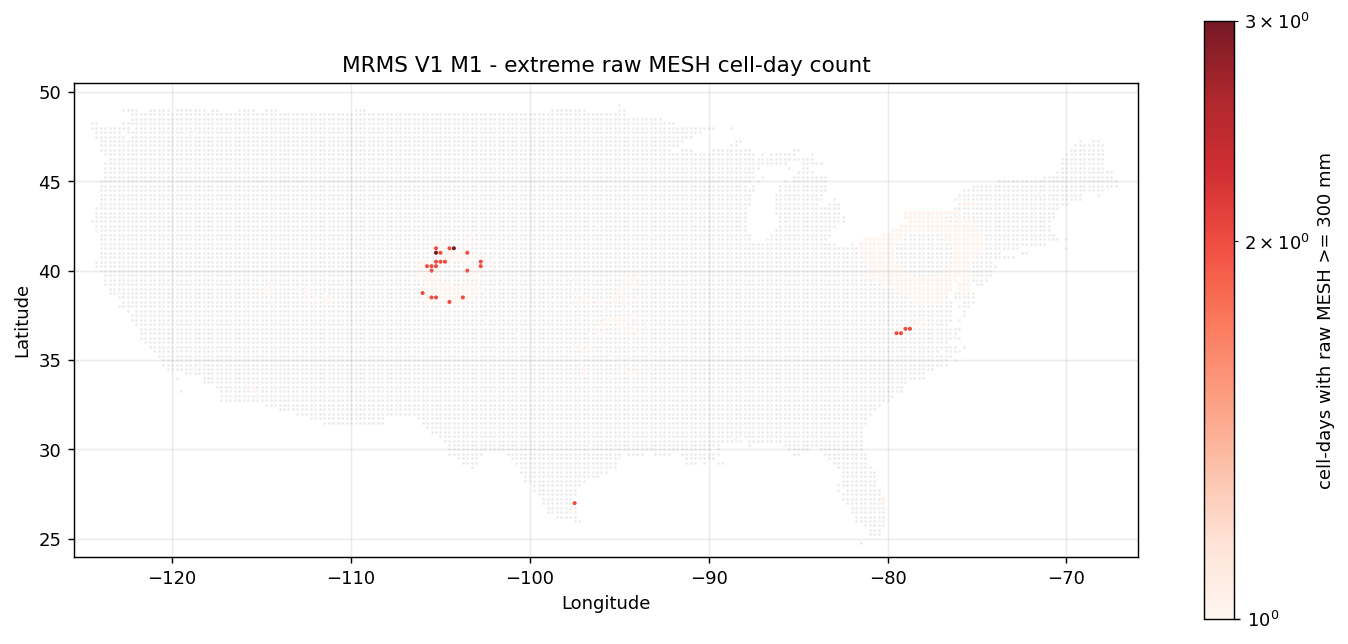

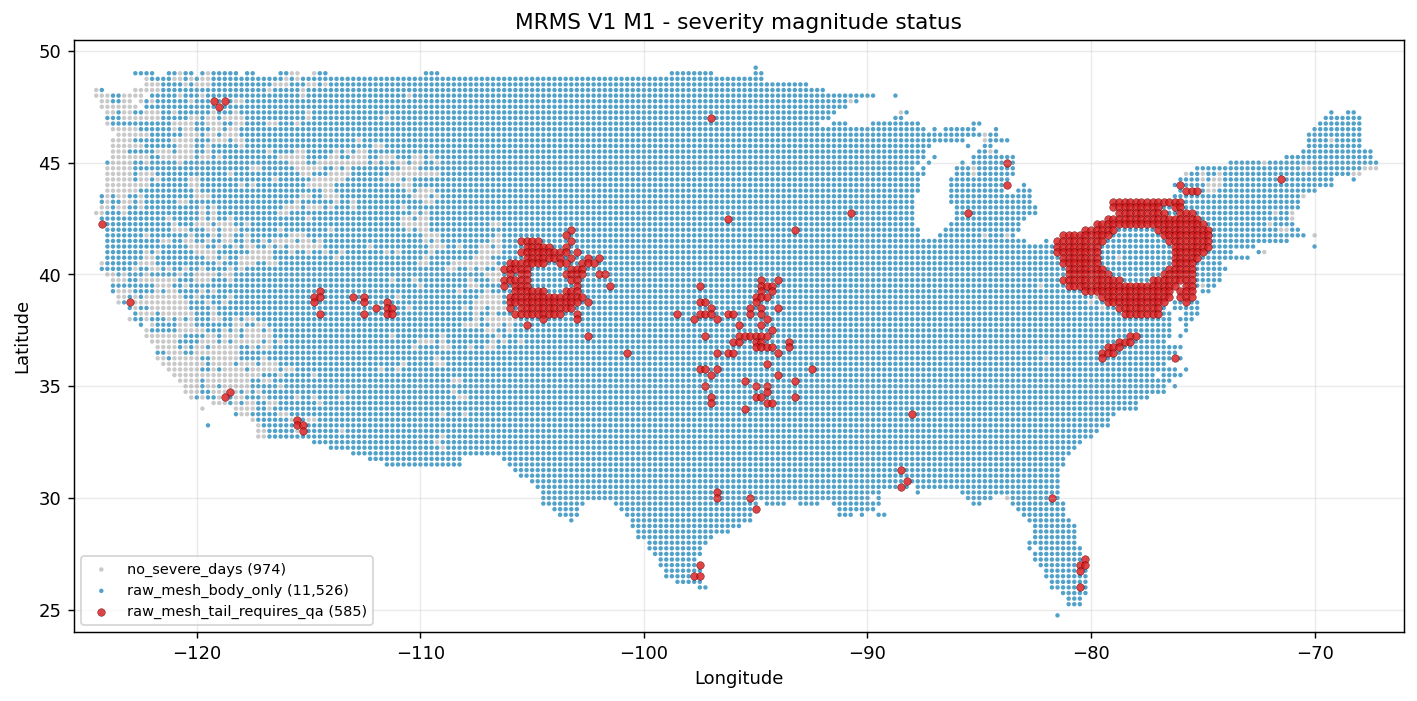

In [5]:
MAP_DIR.mkdir(parents=True, exist_ok=True)


def base_map(ax: plt.Axes, title: str) -> None:
    ax.set_title(title)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_xlim(-125.5, -66.0)
    ax.set_ylim(24.0, 50.5)
    ax.set_aspect("equal", adjustable="box")


def plot_positive_metric(
    frame: pd.DataFrame,
    metric: str,
    title: str,
    output_name: str,
    colorbar_label: str,
    *,
    cmap: str = "viridis",
    log_scale: bool = False,
) -> Path:
    path = MAP_DIR / output_name
    fig, ax = plt.subplots(figsize=(11, 6.2))
    ax.scatter(frame["lon_center"], frame["lat_center"], s=2.2, c="#d9d9d9", linewidths=0, alpha=0.55)
    plotted = frame[frame[metric].fillna(0) > 0].copy()
    norm = None
    if log_scale and not plotted.empty:
        norm = LogNorm(vmin=max(float(plotted[metric].min()), 1.0), vmax=float(plotted[metric].max()))
    scatter = ax.scatter(
        plotted["lon_center"],
        plotted["lat_center"],
        s=5,
        c=plotted[metric],
        cmap=cmap,
        norm=norm,
        linewidths=0,
        alpha=0.9,
    )
    if not plotted.empty:
        cbar = fig.colorbar(scatter, ax=ax, shrink=0.78)
        cbar.set_label(colorbar_label)
    base_map(ax, title)
    fig.tight_layout()
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    return path


severe_count_map = plot_positive_metric(
    hazard_layer,
    "n_severe_hail_days",
    "MRMS V1 M1 - severe hail cell-days",
    f"mrms_v1_m1_severe_hail_days_{M1_RUN_ID}.png",
    "severe hail cell-days",
    cmap="magma",
    log_scale=True,
)

lambda_map = plot_positive_metric(
    hazard_layer,
    "lambda_cell_raw",
    "MRMS V1 M1 - raw annual severe hail-day rate",
    f"mrms_v1_m1_lambda_cell_raw_{M1_RUN_ID}.png",
    "severe hail cell-days/year",
    cmap="plasma",
)

hazard_layer["max_mesh_mm_log1p_display"] = np.log1p(hazard_layer["max_mesh_mm_raw_any_day"].fillna(0))
mesh_log_map = plot_positive_metric(
    hazard_layer,
    "max_mesh_mm_log1p_display",
    "MRMS V1 M1 - max raw MESH, log1p display scale",
    f"mrms_v1_m1_max_mesh_log1p_{M1_RUN_ID}.png",
    "log1p(max raw MESH mm)",
    cmap="inferno",
)

extreme_count_map = plot_positive_metric(
    hazard_layer,
    "extreme_mesh_cell_day_count",
    "MRMS V1 M1 - extreme raw MESH cell-day count",
    f"mrms_v1_m1_extreme_mesh_cell_day_count_{M1_RUN_ID}.png",
    "cell-days with raw MESH >= 300 mm",
    cmap="Reds",
    log_scale=True,
)

status_map = MAP_DIR / f"mrms_v1_m1_severity_magnitude_status_{M1_RUN_ID}.png"
status_colors = {
    "no_severe_days": "#bdbdbd",
    "raw_mesh_body_only": "#2b8cbe",
    "raw_mesh_tail_requires_qa": "#d7191c",
}
fig, ax = plt.subplots(figsize=(11, 6.2))
for status, group in hazard_layer.groupby("severity_magnitude_status"):
    ax.scatter(
        group["lon_center"],
        group["lat_center"],
        s=6 if status != "raw_mesh_tail_requires_qa" else 18,
        c=status_colors.get(status, "#636363"),
        linewidths=0.25 if status == "raw_mesh_tail_requires_qa" else 0,
        edgecolors="#4d0000" if status == "raw_mesh_tail_requires_qa" else "none",
        alpha=0.82,
        label=f"{status} ({len(group):,})",
    )
ax.legend(loc="lower left", fontsize=8, frameon=True)
base_map(ax, "MRMS V1 M1 - severity magnitude status")
fig.tight_layout()
fig.savefig(status_map, bbox_inches="tight")
plt.show()

map_paths = [severe_count_map, lambda_map, mesh_log_map, extreme_count_map, status_map]

**Takeaway.** The frequency maps are the primary V1 hazard-screening view. The log-scaled max-MESH and
severity-status maps are QA views that keep the raw tail visible without treating it as calibrated severity.

## 4 - Write M1 artifacts and metadata

In [6]:
TABLE_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.DataFrame(
    [
        ("m1_rows", len(hazard_layer), "cells", "one row per served CONUS cell"),
        ("input_m0_dates", expected_dates, "dates", "accepted MRMS denominator"),
        ("input_m0_rows", expected_rows, "cell-days", "reconciled M0 rows summarized"),
        ("cells_with_any_severe_hail_day", int((hazard_layer["n_severe_hail_days"] > 0).sum()), "cells", "frequency support"),
        ("cells_with_no_severe_hail_days", int((hazard_layer["n_severe_hail_days"] == 0).sum()), "cells", "zero severe-day cells"),
        ("cells_with_extreme_mesh_ge_300mm", int(hazard_layer["extreme_mesh_ge_300mm_flag"].sum()), "cells", "severity-tail QA"),
        ("extreme_mesh_cell_days", int(hazard_layer["extreme_mesh_cell_day_count"].sum()), "cell-days", "raw MESH >= 300 mm"),
        ("max_lambda_cell_raw", float(hazard_layer["lambda_cell_raw"].max()), "days/year", "raw annualized frequency proxy"),
        ("max_raw_mesh_mm_any_day", float(hazard_layer["max_mesh_mm_raw_any_day"].max()), "mm", "raw MESH maximum, not calibrated hail size"),
    ],
    columns=["item", "value", "unit/base", "interpretation"],
)
display(summary)

top_cells = hazard_layer.sort_values(["n_severe_hail_days", "max_mesh_mm_raw_any_day"], ascending=False).head(250)

hazard_layer.to_parquet(HAZARD_LAYER_PARQUET, index=False)
hazard_layer.head(500).to_csv(HAZARD_LAYER_CSV, index=False)
summary.to_csv(SUMMARY_CSV, index=False)
top_cells.to_csv(TOP_CELLS_CSV, index=False)

metadata = {
    "artifact_family": "mrms_v1_m1_hazard_layer",
    "status": "m1_artifact_created",
    "m1_run_id": M1_RUN_ID,
    "input_m0_reconciled_run_id": RECONCILED_RUN_ID,
    "input_m0_local_root": str(RECONCILED_ROOT),
    "input_m0_gcs_root": reconciled_metadata.get("gcs_run_root"),
    "m1_local_root": str(M1_ROOT),
    "m1_gcs_root": M1_GCS_ROOT,
    "source_set": "MRMS_ONLY",
    "source_product": "CONUS/MESH_Max_1440min_00.50",
    "threshold_mm": 25.4,
    "record_span": {
        "start": str(pd.to_datetime(date_coverage["date"]).min().date()),
        "end": str(pd.to_datetime(date_coverage["date"]).max().date()),
        "accepted_source_dates": expected_dates,
    },
    "input_contract": {
        "served_cells": expected_cells,
        "m0_rows": expected_rows,
        "partition_files": len(partition_paths),
        "streamed_rows": int(m1_diag["streamed_rows"]),
        "duplicate_cell_date_rows": int(m1_diag["duplicate_cell_date_rows"]),
        "bad_daily_row_counts": m1_diag["bad_daily_row_counts"],
    },
    "summary": summary.to_dict(orient="records"),
    "frequency_policy": {
        "event_unit": "severe_hail_cell_day",
        "severe_threshold_mm": 25.4,
        "lambda_cell_raw": "n_severe_hail_days / (n_observed_days / 365.25)",
        "freq_dist": "poisson_v1_default",
        "fano_phi_complete_years": "diagnostic only, not default fit",
    },
    "severity_policy": {
        "raw_mesh_preserved": True,
        "extreme_mesh_threshold_mm": 300.0,
        "extreme_mesh_policy": "flag and preserve as event/context evidence; do not treat as literal size without QA rule",
        "severity_magnitude_status_values": sorted(hazard_layer["severity_magnitude_status"].dropna().unique().tolist()),
    },
    "plausibility_qc": qc_summary,
    "outputs": {
        "hazard_layer_parquet": str(HAZARD_LAYER_PARQUET),
        "hazard_layer_preview_csv": str(HAZARD_LAYER_CSV),
        "summary_csv": str(SUMMARY_CSV),
        "top_cells_csv": str(TOP_CELLS_CSV),
        "maps": [str(path) for path in map_paths],
        "metadata_json": str(METADATA_JSON),
    },
    "allowed_use": [
        "MRMS-only full-CONUS screening",
        "frequency comparison across served grid cells",
        "input to provisional M2-M4 smoke runs with tail warnings",
    ],
    "not_allowed_use": [
        "final calibrated hail climatology",
        "reportable EAL/PML/VaR/TVaR",
        "raw extreme-MESH-driven loss severity",
    ],
    "caveats": [
        "Raw MRMS MESH is radar-estimated and not de-biased.",
        "Frequency is an operational-era MRMS-only severe cell-day rate.",
        "Poisson is the V1 default; annual over-dispersion is diagnostic only.",
        "Raw MESH size summaries are provisional and carry severity-tail QA flags.",
        "MYRORSS, Storm Events calibration, Murillo/Homeyer de-biasing, and EVT tails are deferred to V1.5/V2.",
    ],
}

METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")

print("wrote M1 hazard layer:", HAZARD_LAYER_PARQUET.relative_to(ROOT))
print("wrote summary:", SUMMARY_CSV.relative_to(ROOT))
print("wrote metadata:", METADATA_JSON.relative_to(ROOT))

,item,value,unit/base,interpretation
0,m1_rows,1.308500e+04,cells,one row per served CONUS cell
1,input_m0_dates,2.071000e+03,dates,accepted MRMS denominator
2,input_m0_rows,2.709904e+07,cell-days,reconciled M0 rows summarized
3,cells_with_any_severe_hail_day,1.211100e+04,cells,frequency support
4,cells_with_no_severe_hail_days,9.740000e+02,cells,zero severe-day cells
5,cells_with_extreme_mesh_ge_300mm,5.850000e+02,cells,severity-tail QA
6,extreme_mesh_cell_days,6.130000e+02,cell-days,raw MESH >= 300 mm
7,max_lambda_cell_raw,4.497284e+01,days/year,raw annualized frequency proxy
8,max_raw_mesh_mm_any_day,1.437400e+03,mm,"raw MESH maximum, not calibrated hail size"


wrote M1 hazard layer: data/hazard_conus_grid/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only/tables/mrms_v1_m1_hazard_layer_20260618T040000Z_m1_mrms_only.parquet
wrote summary: data/hazard_conus_grid/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only/tables/mrms_v1_m1_summary_20260618T040000Z_m1_mrms_only.csv
wrote metadata: data/hazard_conus_grid/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only/metadata_20260618T040000Z_m1_mrms_only.json


## 5 - Optional GCS upload

In [7]:
def is_gcs_uri(value: str) -> bool:
    return value.startswith("gs://")


def split_gcs_uri(uri: str) -> tuple[str, str]:
    rest = uri[5:]
    bucket, _, blob = rest.partition("/")
    if not bucket or not blob:
        raise ValueError(f"invalid GCS URI: {uri}")
    return bucket, blob


def gcs_prefix_exists(uri: str) -> bool:
    try:
        from google.cloud import storage  # type: ignore
    except Exception:
        result = subprocess.run(
            ["gcloud", "storage", "ls", f"{uri.rstrip('/')}/**"],
            text=True,
            stdout=subprocess.PIPE,
            stderr=subprocess.PIPE,
            check=False,
        )
        return result.returncode == 0

    bucket_name, prefix = split_gcs_uri(uri.rstrip("/") + "/_probe")
    prefix = prefix.rsplit("/", 1)[0].rstrip("/") + "/"
    return any(storage.Client().bucket(bucket_name).list_blobs(prefix=prefix, max_results=1))


def upload_file(local_path: Path, destination_uri: str) -> None:
    try:
        from google.cloud import storage  # type: ignore
    except Exception:
        subprocess.run(["gcloud", "storage", "cp", str(local_path), destination_uri], check=True)
        return

    bucket_name, blob_name = split_gcs_uri(destination_uri)
    storage.Client().bucket(bucket_name).blob(blob_name).upload_from_filename(local_path)


def upload_tree(local_root: Path, gcs_root: str) -> list[str]:
    if gcs_prefix_exists(gcs_root) and not FORCE_M1_OUTPUT:
        raise FileExistsError(f"GCS M1 prefix already exists: {gcs_root}")

    uploaded: list[str] = []
    for path in sorted(p for p in local_root.rglob("*") if p.is_file()):
        rel = path.relative_to(local_root).as_posix()
        destination = f"{gcs_root.rstrip('/')}/{rel}"
        upload_file(path, destination)
        uploaded.append(destination)
    return uploaded


if UPLOAD_TO_GCS:
    uploaded = upload_tree(M1_ROOT, M1_GCS_ROOT)
    metadata["upload_status"] = "uploaded"
    metadata["uploaded_gcs_outputs"] = uploaded
    METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
    upload_file(METADATA_JSON, f"{M1_GCS_ROOT.rstrip('/')}/{METADATA_JSON.name}")
    print(f"uploaded {len(uploaded):,} files to {M1_GCS_ROOT}")
else:
    metadata["upload_status"] = "not_requested"
    metadata["uploaded_gcs_outputs"] = []
    METADATA_JSON.write_text(json.dumps(metadata, indent=2) + "\n")
    print("GCS upload not requested")

/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


...

/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


/Users/divy/code/work/infrasure_git_codes/Hazard_modeling/.venv/lib/python3.12/site-packages/google/auth/_default.py:113: UserWarning: Your application has authenticated using end user credentials from Google Cloud SDK without a quota project. You might receive a "quota exceeded" or "API not enabled" error. See the following page for troubleshooting: https://cloud.google.com/docs/authentication/adc-troubleshooting/user-creds. 
  warnings.warn(_CLOUD_SDK_CREDENTIALS_WARNING)


uploaded 10 files to gs://infrasure-benchmark/hazard_conus_grid/dev/hail/v1_mrms_only/m1_hazard_layer/run_id=20260618T040000Z_m1_mrms_only


## 6 - Recap and next step

This notebook produced the first full-CONUS MRMS-only M1 hazard layer.

### What the data is telling us

The M0->M1 mechanics are working:

- every served cell has the same accepted MRMS denominator: `2,071` observed source dates;
- the M1 artifact has one row per served CONUS cell: `13,085` cells;
- the broad frequency geography is directionally credible, with the central hail corridor dominating the
  severe cell-day counts;
- the pipeline preserves source, threshold, coverage, frequency, raw size, and QA provenance in one M1 row.

The same artifact also shows why M2-M4 must be labeled and guarded:

- `12,111` cells have at least one severe hail day;
- `974` cells have no severe hail days and should exercise zero-event handling downstream;
- `11,526` cells are `raw_mesh_body_only`;
- `585` cells are `raw_mesh_tail_requires_qa`;
- the maximum raw MESH value is physically implausible as literal hail size, so raw MESH tail values must not
  silently drive final loss.

### What is ready now

- one row per served `cell_id`;
- raw annual severe-hail cell-day rate;
- Poisson V1 default frequency declaration;
- raw/provisional MESH size summaries;
- explicit severity-tail QA flags.

This is enough for full-CONUS screening and selected-cell M2-M4 smoke tests.

### What is not ready yet

- MESH de-biasing;
- MYRORSS extension;
- report-side calibration;
- EVT tail modeling;
- reportable risk metrics.

It is not enough for final EAL / VaR / PML / TVaR.

### M2-M4 readiness gate

The next M2-M4 step should be selected-cell only, not full-CONUS loss production. The smoke set should include:

- one central hail-corridor body cell;
- one moderate body cell;
- one no-severe cell;
- one suspicious high-frequency cell;
- one raw-MESH tail-QA cell.

Downstream outputs must carry:

```text
source_set = MRMS_ONLY
version = V1
severity_policy = provisional
allowed_use = screening_or_smoke
not_allowed_use = reportable_loss_metrics
```

Recommended next step:

```text
accept M1 handoff policy
  -> select M2-M4 smoke cells from this M1 artifact
  -> run canonical solar M2-M4 smoke with provisional-tail metadata
  -> review raw-vs-capped/log severity sensitivity before any full-CONUS scaleout
```